In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight


In [8]:
train_dir = "train"
valid_dir = "valid"

In [9]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=True
)

Found 7000 files belonging to 2 classes.


In [10]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=False   
)

Found 3000 files belonging to 2 classes.


In [11]:
print("Class Names:", training_set.class_names)

Class Names: ['fake', 'real']


In [14]:
labels = np.concatenate([y.numpy() for x,y in training_set], axis=0)
labels = np.argmax(labels, axis=1)

unique, counts = np.unique(labels, return_counts=True)
print("Training Class Distribution:", dict(zip(unique, counts)))

Training Class Distribution: {0: 3500, 1: 3500}


In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: 1.0, 1: 1.0}


In [16]:
#prefetch
AUTOTUNE = tf.data.AUTOTUNE

training_set = training_set.prefetch(buffer_size=AUTOTUNE)
validation_set = validation_set.prefetch(buffer_size=AUTOTUNE)

In [ ]:
model = tf.keras.models.Sequential([

    # NORMALIZATION INSIDE MODEL
    tf.keras.layers.Rescaling(1./255, input_shape=(128,128,3)),

    tf.keras.layers.Conv2D(32,3,activation='relu',padding="same"),
    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,3,activation='relu',padding="same"),
    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,3,activation='relu',padding="same"),
    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(2,activation='softmax')
])

c:\Users\Gopal Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,133,602 (50.10 MB)

 Trainable params: 13,133,602 (50.10 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    class_weight=class_weights
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 223s 994ms/step - accuracy: 0.5603 - loss: 0.6790 - val_accuracy: 0.6747 - val_loss: 0.5989
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.6895 - loss: 0.5994 - val_accuracy: 0.7077 - val_loss: 0.5680
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 168s 766ms/step - accuracy: 0.7118 - loss: 0.5525 - val_accuracy: 0.7477 - val_loss: 0.5149
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 190s 867ms/step - accuracy: 0.7436 - loss: 0.5141 - val_accuracy: 0.7657 - val_loss: 0.4871
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 166s 759ms/step - accuracy: 0.7739 - loss: 0.4725 - val_accuracy: 0.7467 - val_loss: 0.5127
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 165s 755ms/step - accuracy: 0.7863 - loss: 0.4508 - val_accuracy: 0.7877 - val_loss: 0.4455
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 162s 739ms/step - accuracy: 0.8296 - loss: 0.3820 - val_accuracy: 0.7887 - val_loss: 0.4554
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 167s 760ms/step - accuracy: 0.8527 - lo

In [20]:
## Model Evaluation on Training set
train_loss, train_acc = model.evaluate(training_set)
print("Training Accuracy:", train_acc)

219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 131ms/step - accuracy: 0.9986 - loss: 0.0117
Training Accuracy: 0.99871426820755


In [21]:
## Model evaluation on validation set
val_loss, val_acc = model.evaluate(validation_set)
print("Validation Accuracy:", val_acc)


94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 0.8528 - loss: 0.5547
Validation Accuracy: 0.840666651725769


In [22]:
model.save("Trained_model.h5")

In [23]:
model.save("Trained_model.keras")

In [24]:
history.history

{'accuracy': [0.6095714569091797,
  0.6984285712242126,
  0.728857159614563,
  0.7612857222557068,
  0.7855714559555054,
  0.807285726070404,
  0.8410000205039978,
  0.86814284324646,
  0.8825713992118835,
  0.9081428647041321,
  0.928428590297699,
  0.9419999718666077,
  0.9580000042915344,
  0.9652857184410095,
  0.9727143049240112,
  0.9764285683631897,
  0.982285737991333,
  0.979285717010498,
  0.984000027179718,
  0.9879999756813049],
 'loss': [0.6528094410896301,
  0.5866076946258545,
  0.5363107323646545,
  0.4927549958229065,
  0.4611664116382599,
  0.42018553614616394,
  0.3649436831474304,
  0.3149597644805908,
  0.27494558691978455,
  0.22986145317554474,
  0.18504925072193146,
  0.15335071086883545,
  0.11653468757867813,
  0.09742124378681183,
  0.07442719489336014,
  0.06654483079910278,
  0.052256882190704346,
  0.05398057401180267,
  0.04824278503656387,
  0.03909468650817871],
 'val_accuracy': [0.6746666431427002,
  0.7076666951179504,
  0.7476666569709778,
  0.765666

In [25]:
## Recording history in json Formate
import json
with open("training_hist.json","w") as f:
    json.dump(history.history,f)

In [26]:
history.history['accuracy']

[0.6095714569091797,
 0.6984285712242126,
 0.728857159614563,
 0.7612857222557068,
 0.7855714559555054,
 0.807285726070404,
 0.8410000205039978,
 0.86814284324646,
 0.8825713992118835,
 0.9081428647041321,
 0.928428590297699,
 0.9419999718666077,
 0.9580000042915344,
 0.9652857184410095,
 0.9727143049240112,
 0.9764285683631897,
 0.982285737991333,
 0.979285717010498,
 0.984000027179718,
 0.9879999756813049]

In [27]:
history.history['val_accuracy']

[0.6746666431427002,
 0.7076666951179504,
 0.7476666569709778,
 0.765666663646698,
 0.746666669845581,
 0.7876666784286499,
 0.7886666655540466,
 0.79666668176651,
 0.8029999732971191,
 0.815666675567627,
 0.8016666769981384,
 0.8226666450500488,
 0.8243333101272583,
 0.8353333473205566,
 0.8366666436195374,
 0.8356666564941406,
 0.8339999914169312,
 0.8256666660308838,
 0.8399999737739563,
 0.840666651725769]

In [28]:
# Accuracy Visualization
epochs=[i for i in range(1,21)]
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

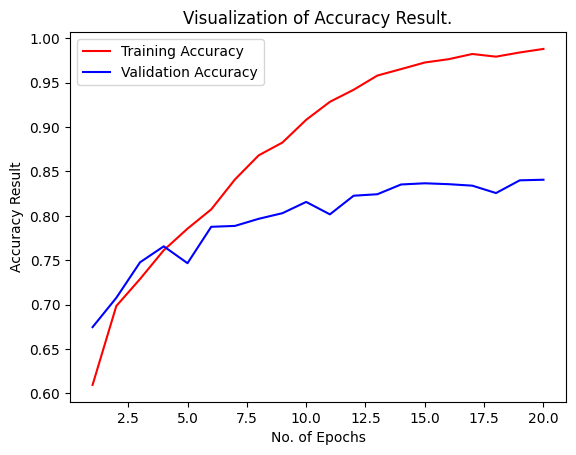

In [29]:
plt.plot(epochs,history.history['accuracy'],color='Red',label='Training Accuracy')
plt.plot(epochs,history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result.")
plt.legend()
plt.show()

In [30]:
#Test set
test_set = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128,128),
    shuffle=False
)

Found 3000 files belonging to 2 classes.


In [31]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step


In [32]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [33]:
Y_true

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 0, 0, ..., 1, 1, 1], dtype=int64)>

In [34]:
predicted_categories

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 0, 0, ..., 0, 0, 1], dtype=int64)>

In [35]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

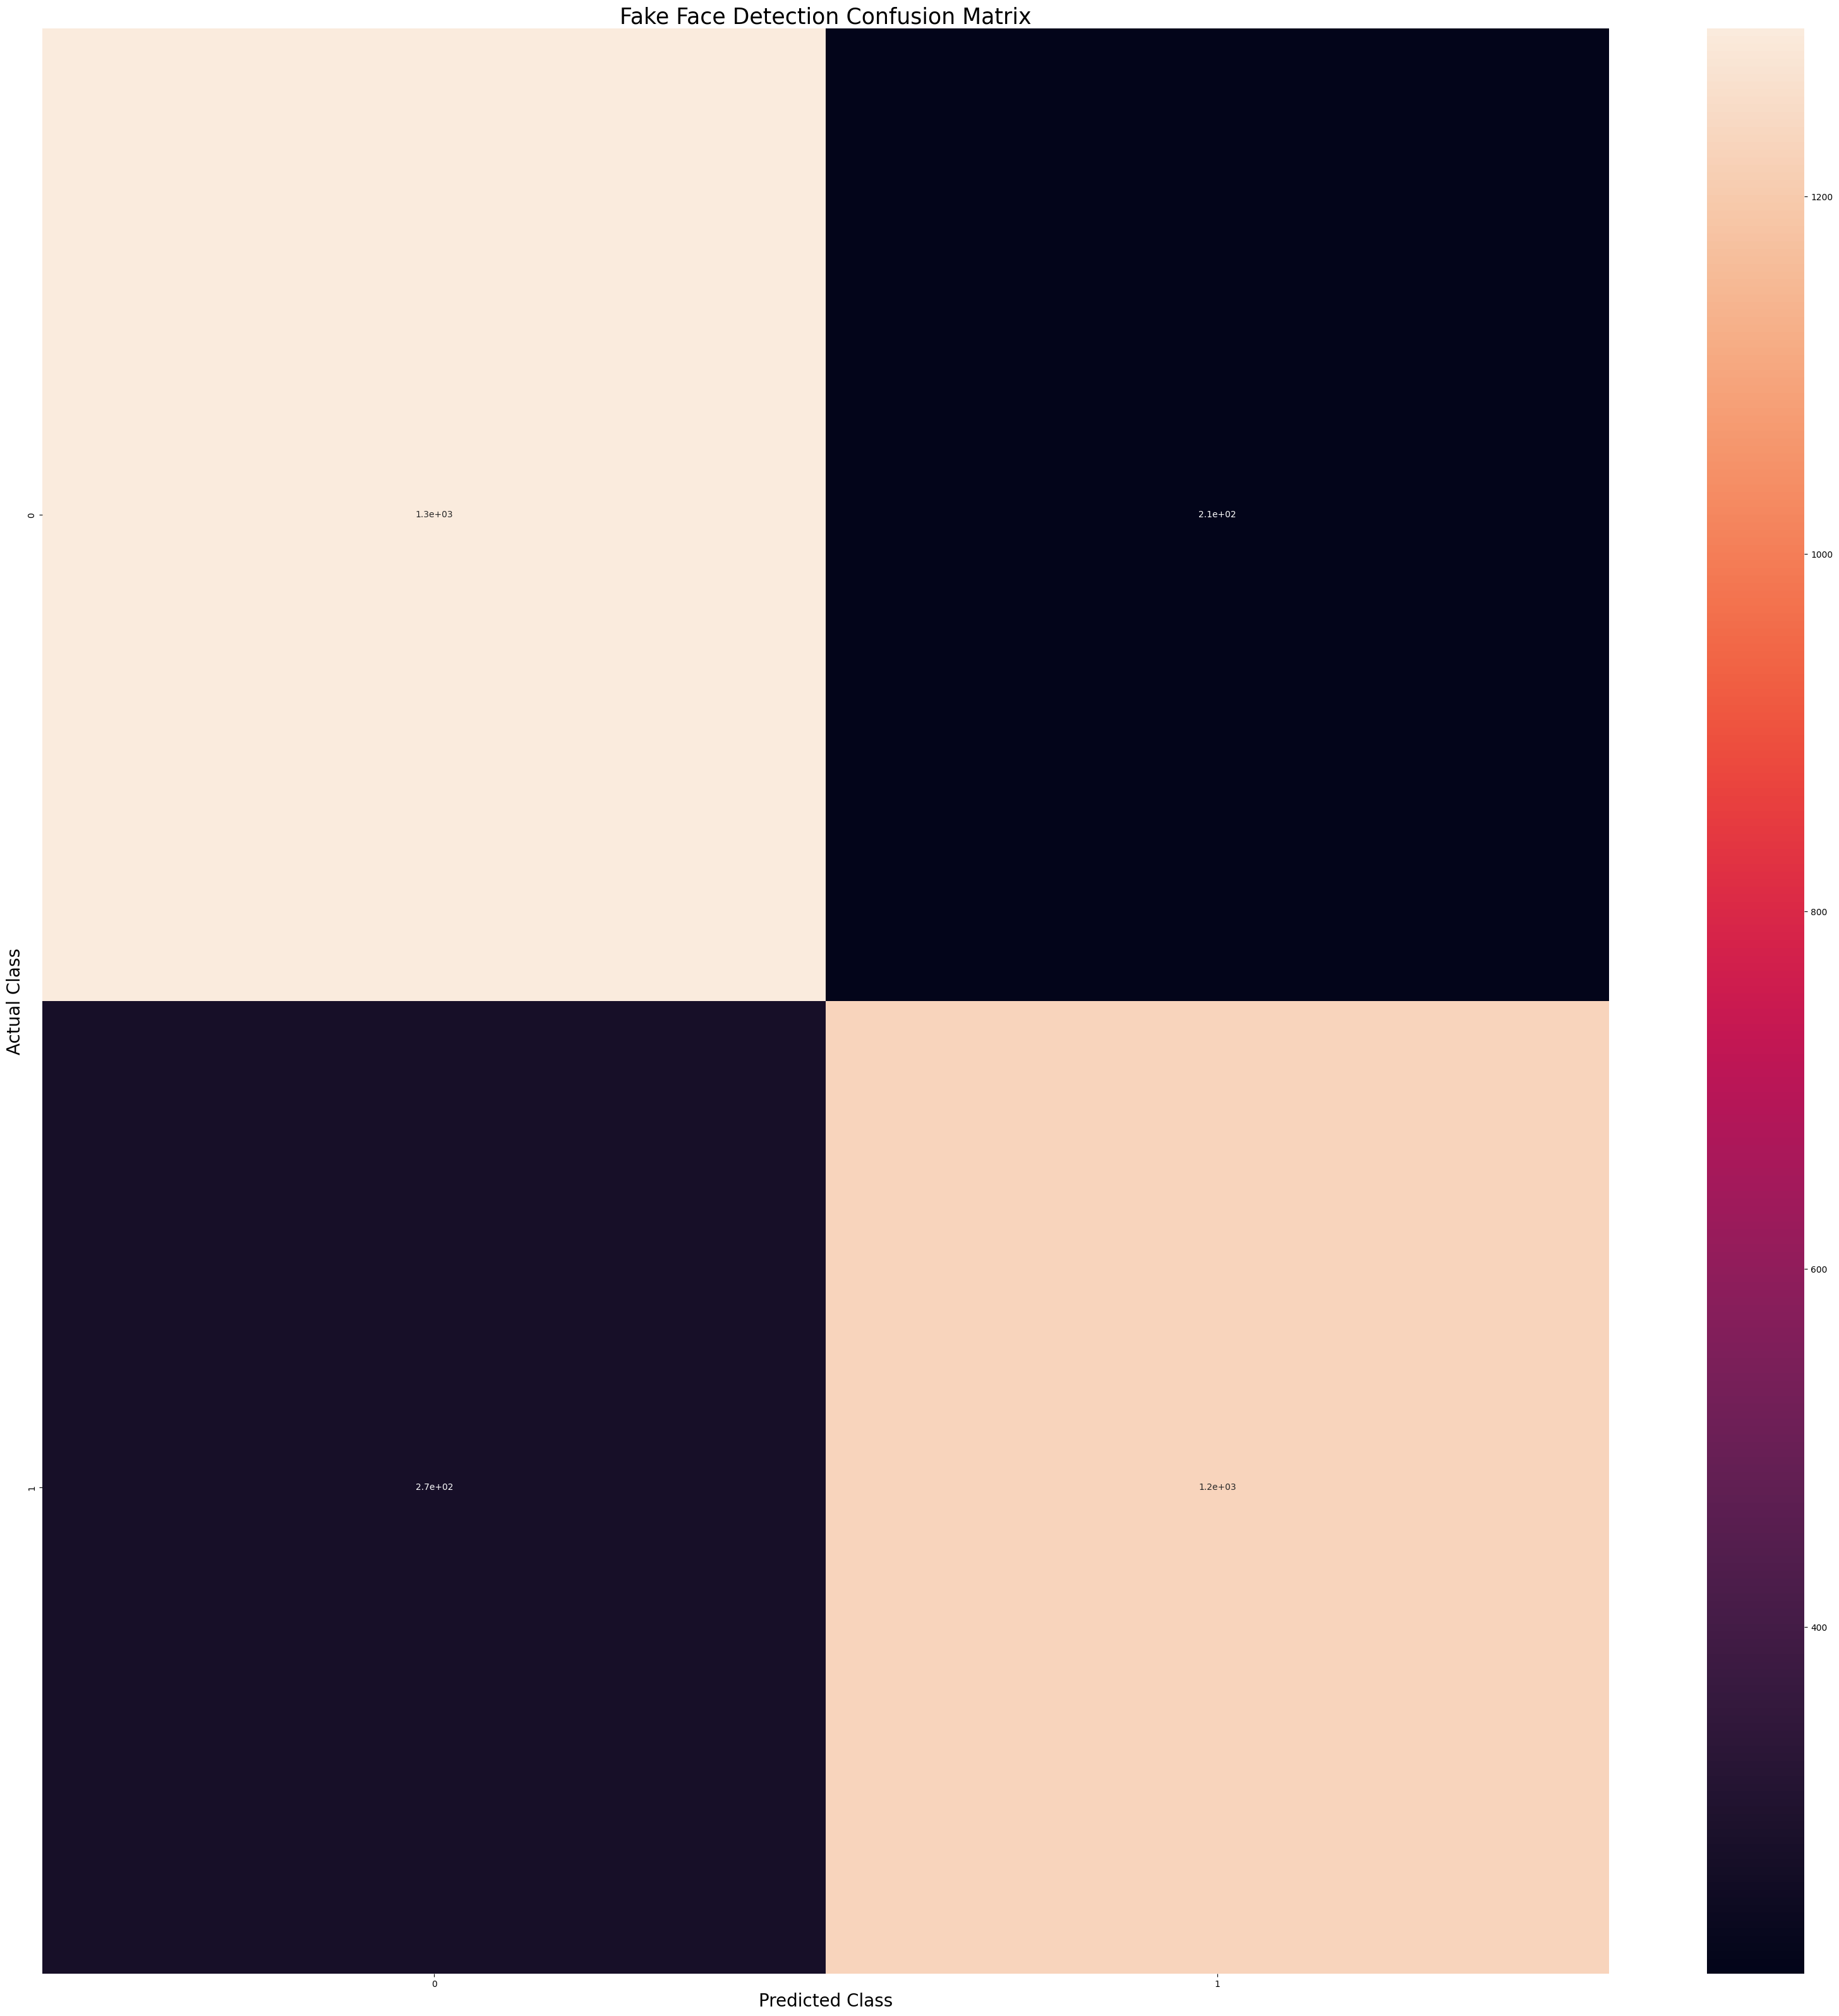

In [36]:
# confusion matrix visualization
import seaborn as sns
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Fake Face Detection Confusion Matrix',fontsize = 25)
plt.show()